Getting argo data and evaluating if there are enough profiles for the years

In [8]:
from argopy import DataFetcher
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.interpolate import PchipInterpolator
import random
import urllib.request
import tempfile
import os
from datetime import timedelta
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score, 
                             average_precision_score, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay)
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve



In [ ]:
def downloadArgoData(box):
    fetcher = DataFetcher(src='erddap').region(box)
    ds = fetcher.to_xarray()

    ds.to_netcdf('argo_florida_keys_raw.nc')
    print('Argo data downloaded')


Below we define our area of research, a bounding box around Florida Keys. We specify the data range from January 2010 to December 2025

In [58]:
box = [-83.5, -79.5, 23.5, 26.0, 0, 300, '2010-01', '2025-12']
downloadArgoData(box)

Argo data downloaded


Load the downloaded data

In [2]:
filePath='argo_florida_keys_raw.nc'
ds=xr.open_dataset(filePath)

See one of the profiles

In [3]:
df = ds.to_dataframe().reset_index()

grouped = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])
first_key = next(iter(grouped.groups))
first_profile = grouped.get_group(first_key)

print('First profile key (PLATFORM_NUMBER, CYCLE_NUMBER):', first_key)
print(first_profile)
print('Number of pressure levels in first profile:', first_profile['TEMP'].count())
print('Number of pressure levels in first profile:', first_profile['PRES'].count())

First profile key (PLATFORM_NUMBER, CYCLE_NUMBER): (3901987, 216)
       N_POINTS  CYCLE_NUMBER DATA_MODE DIRECTION  PLATFORM_NUMBER  \
26556     26556           216         D         A          3901987   
26557     26557           216         D         A          3901987   
26558     26558           216         D         A          3901987   
26559     26559           216         D         A          3901987   
26560     26560           216         D         A          3901987   
...         ...           ...       ...       ...              ...   
26739     26739           216         D         A          3901987   
26740     26740           216         D         A          3901987   
26741     26741           216         D         A          3901987   
26742     26742           216         D         A          3901987   
26743     26743           216         D         A          3901987   

       POSITION_QC        PRES  PRES_ERROR  PRES_QC       PSAL  PSAL_ERROR  \
26556          

Plot the argo profiles yearwise, on the map

In [6]:
def plotData(ds):
    ds=ds.copy()
    df = ds.to_dataframe().reset_index()
    lon_min, lon_max, lat_min, lat_max = -83.5, -79.5, 23.5, 26.0
    df['year'] = df['TIME'].dt.year


    years = sorted(df['year'].unique())
    n_years = len(years)

    cols = 4
    rows_for_years = int(np.ceil(n_years / cols))
    total_rows = 1 + rows_for_years

    fig = plt.figure(figsize=(18, 4 + rows_for_years * 4))
    gs = fig.add_gridspec(total_rows, cols, hspace=0.35, wspace=0.3)

    ax_main = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
    ax_main.add_feature(cfeature.LAND, facecolor='lightgray')
    ax_main.add_feature(cfeature.COASTLINE)
    ax_main.add_feature(cfeature.BORDERS, linestyle=':')

    scatter = ax_main.scatter(df['LONGITUDE'], df['LATITUDE'], 
                            c=df['TIME'].dt.year, cmap='viridis', 
                            s=15, alpha=0.7, transform=ccrs.PlateCarree())

    ax_main.plot([lon_min, lon_max, lon_max, lon_min, lon_min],
                [lat_min, lat_min, lat_max, lat_max, lat_min],
                color='red', linestyle='--', transform=ccrs.PlateCarree(), linewidth=2, label='Study Area')

    ax_main.set_extent([-85, -78, 22, 28])
    ax_main.set_title(f"All Years Combined - {len(df)} Total Profiles (2010-2025)", fontsize=14, fontweight='bold')
    ax_main.legend(loc='upper right')
    cbar = plt.colorbar(scatter, ax=ax_main, label='Year', shrink=0.8)

    for idx, year in enumerate(years):
        row = 1 + idx // cols
        col = idx % cols
        
        ax_year = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        
        df_year = df[df['year'] == year]
        year_count = len(df_year)
        
        ax_year.add_feature(cfeature.LAND, facecolor='lightgray')
        ax_year.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax_year.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
        
        ax_year.scatter(df_year['LONGITUDE'], df_year['LATITUDE'], 
                    c='steelblue', s=20, alpha=0.7, 
                    transform=ccrs.PlateCarree(), edgecolors='darkblue', linewidth=0.3)
        
        ax_year.plot([lon_min, lon_max, lon_max, lon_min, lon_min],
                [lat_min, lat_min, lat_max, lat_max, lat_min],
                color='red', linestyle='--', transform=ccrs.PlateCarree(), linewidth=1)
        
        ax_year.set_extent([-85, -78, 22, 28])
        ax_year.set_title(f"{year}: {year_count} Profiles", fontsize=11, fontweight='bold')
        ax_year.set_xlabel('Longitude', fontsize=9)
        ax_year.set_ylabel('Latitude', fontsize=9)

    for idx in range(n_years, rows_for_years * cols):
        row = 1 + idx // cols
        col = idx % cols
        ax_unused = fig.add_subplot(gs[row, col])
        ax_unused.axis('off')

    plt.suptitle(f"Float Profile Trajectories - Argo Data (Florida Keys, 2010-2025)", 
                fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('argo_trajectories_by_year.png', dpi=300, bbox_inches='tight')
    print(f"\nVisualization saved to 'argo_trajectories_by_year.png'")
    print(f"Total subplots: 1 (all years) + {n_years} (individual years)")
    plt.show()


Visualization saved to 'argo_trajectories_by_year.png'
Total subplots: 1 (all years) + 16 (individual years)


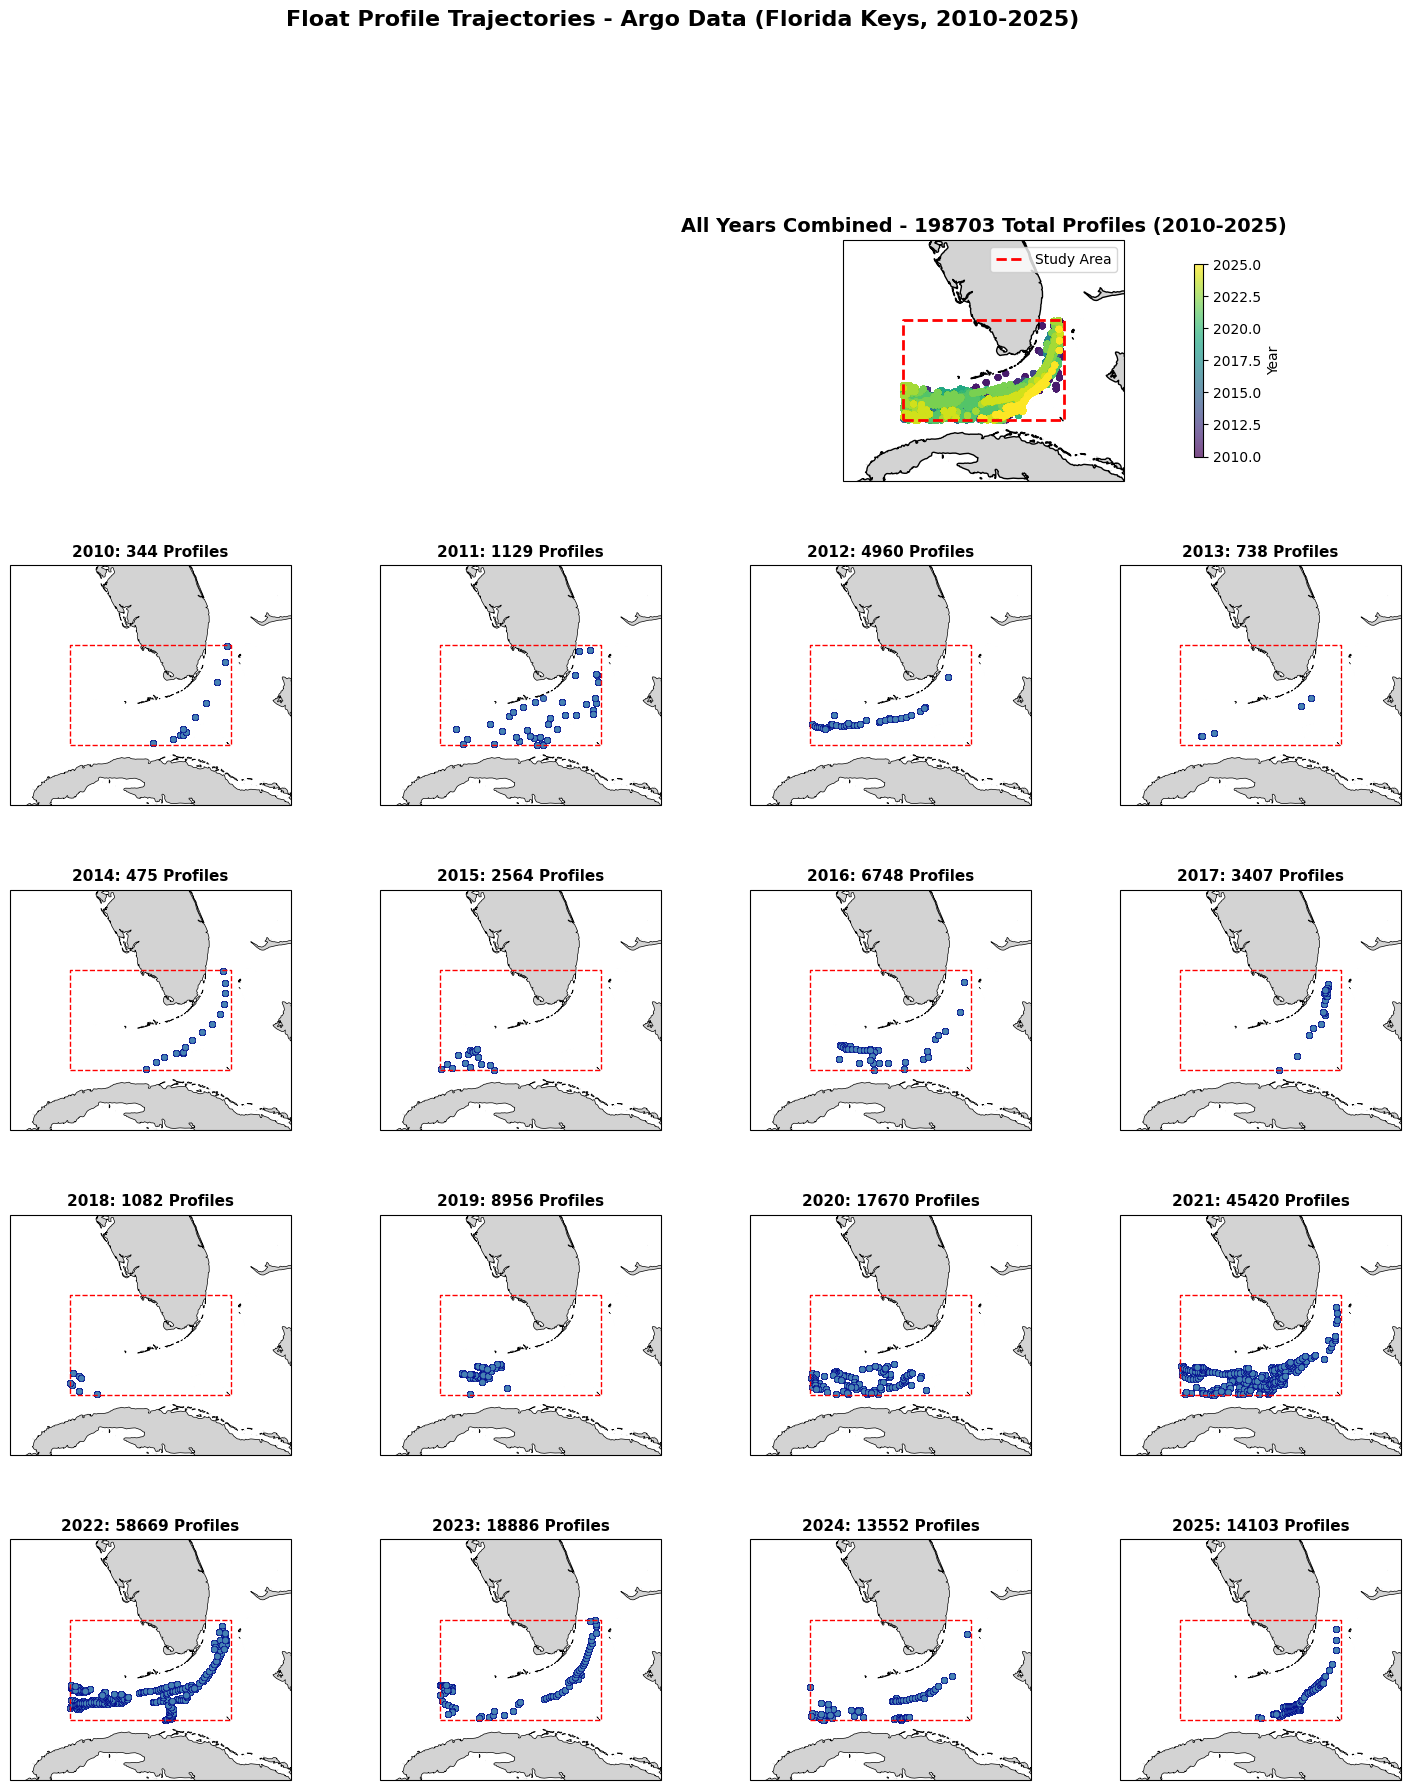

In [7]:
plotData(ds)

Below function gives a better look at the data. We check total number of unique profiles available, depth profile overview, data quality, distribution of readings over the months and years, salinity, temperature distribution

In [ ]:
def checkData(ds):
    df = ds.to_dataframe().reset_index()
    print(len(df))
    # 1. How many unique profiles do you actually have
    n_profiles = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER']).ngroups
    print(f"Unique profiles: {n_profiles}")

    # 2. Depth coverage — what's the max pressure per profile
    max_depth = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].max()
    print(max_depth.describe())

    # See the distribution of all QC flags
    print("Temperature QC breakdown:")
    print(df['TEMP_QC'].value_counts())

    print("\nSalinity QC breakdown:")
    print(df['PSAL_QC'].value_counts())

    print(f"Profiles reaching 200m+: {(max_depth >= 200).sum()}")
    df['month'] = df['TIME'].dt.month
    df['year'] = df['TIME'].dt.year

    print(df.groupby(['year', 'month']).size().unstack())

    profile_depths = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].count()

    print("Depth levels per profile:")
    print(profile_depths.describe())
    print(f"\nMedian depth levels: {profile_depths.median():.0f}")
    print(f"Mode depth levels: {profile_depths.mode()[0]:.0f}")

    # # Distribution to see if it's consistent
    print("\nDistribution:")
    print(profile_depths.value_counts().sort_index())

    plt.figure(figsize=(10, 6))

    sns.histplot(df['PSAL'], kde=True, color='teal', bins=100)

    plt.title('Distribution of Practical Salinity (PSAL)')
    plt.xlabel('Salinity (psu)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.3)
    plt.savefig('PSAL_distribution.png')

    
    plt.clf()
    
    sns.histplot(df['TEMP'], kde=True, color='teal', bins=100)

    plt.title('Distribution of temperature (TEMP)')
    plt.xlabel('Temp (C)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.3)
    plt.savefig('temp_distribution.png')

    temp_stats = df['TEMP'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
    print(temp_stats)

198703
Unique profiles: 1331
count    1331.000000
mean      297.647888
std        14.054590
min        31.000000
25%       299.349991
50%       299.959991
75%       300.000000
max       300.380005
Name: PRES, dtype: float64
Temperature QC breakdown:
TEMP_QC
1    198703
Name: count, dtype: int64

Salinity QC breakdown:
PSAL_QC
1    198703
Name: count, dtype: int64
Profiles reaching 200m+: 1325
month      1       2       3       4       5       6       7       8       9   \
year                                                                            
2010      NaN     NaN     NaN     NaN     NaN     NaN     NaN    31.0   219.0   
2011      NaN    93.0    94.0    32.0   251.0   263.0   114.0     NaN    31.0   
2012    449.0   899.0   898.0   448.0   140.0   423.0   508.0   299.0   298.0   
2013      NaN     NaN   150.0   300.0     NaN     NaN     NaN   288.0     NaN   
2014      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2015      NaN   255.0     NaN     NaN

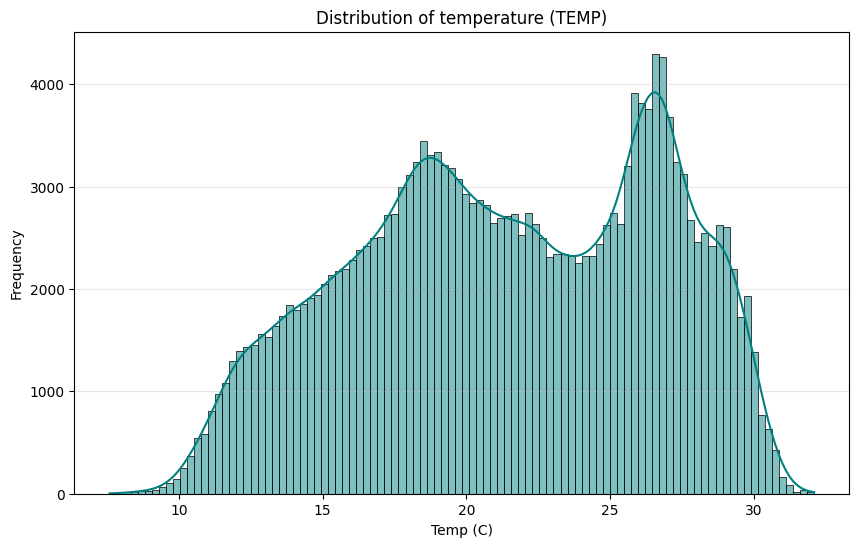

In [8]:
checkData(ds)

From the output, we can see that the data is sparse for the years 2010 to 2018. We need to consider the data distribution for the train/val/test split.

Moving on, we start preparing our data. 

In [5]:
def prepareData(ds):
    df = ds.to_dataframe().reset_index()
    print(f"Profiles before filtering: {df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER']).ngroups}")    
    # Limit to upper 300m
    df = df[df['PRES'] <= 300]

    # Drop profiles with too few depth levels
    MIN_DEPTHS = 25
    profile_counts = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].count()
    valid_idx = profile_counts[profile_counts >= MIN_DEPTHS].index
    df = df.set_index(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    df = df[df.index.isin(valid_idx)].reset_index()

    # Drop profiles not reaching 200m
    profile_max_depth = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].max()
    deep_idx = profile_max_depth[profile_max_depth >= 200].index
    df = df.set_index(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    df = df[df.index.isin(deep_idx)].reset_index()

    # Drop physical outliers
    df = df[(df['TEMP'] > -2) & (df['TEMP'] < 35)]
    df = df[(df['PSAL'] > 30) & (df['PSAL'] < 38)]

    print(f"Profiles after filtering: {df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER']).ngroups}")
    
    return df

In [6]:
df=prepareData(ds)

Profiles before filtering: 1331
Profiles after filtering: 1325


Next, we take a look at the depth resolution of the profiles. The plan is to drop low depth resolution profiles

In [7]:

depth_counts = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].count()

fine   = depth_counts[depth_counts >= 100]   # 2m resolution floats
coarse = depth_counts[(depth_counts >= 25) & (depth_counts < 100)]  # 10m floats
drop   = depth_counts[depth_counts < 25]     # too shallow, drop

print(f"Fine resolution (keep):   {len(fine)} profiles")
print(f"Coarse resolution (keep, interpolates ok): {len(coarse)} profiles")
print(f"Too shallow (drop):       {len(drop)} profiles")

Fine resolution (keep):   1257 profiles
Coarse resolution (keep, interpolates ok): 68 profiles
Too shallow (drop):       0 profiles


Luckily, the few profile that were present in the low count were filtered out in the prepareData step itself

Next, we do a null check on the data

In [8]:
print("TEMP NaN analysis:")
print(f"  Total NaN values: {df['TEMP'].isna().sum()}")
print(f"  Total rows: {len(df)}")
print(f"  NaN %: {df['TEMP'].isna().mean()*100:.2f}%")

print("\nPSAL NaN analysis:")
print(f"  Total NaN values: {df['PSAL'].isna().sum()}")
print(f"  Total rows: {len(df)}")
print(f"  NaN %: {df['PSAL'].isna().mean()*100:.2f}%")

print("\nPRES NaN analysis:")
print(f"  Total NaN values: {df['PRES'].isna().sum()}")

# How many profiles have at least one NaN
profiles_with_nan_temp = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['TEMP'].apply(lambda x: x.isna().any())
print(f"\nProfiles with at least one NaN TEMP: {profiles_with_nan_temp.sum()} / {len(profiles_with_nan_temp)}")

profiles_with_nan_psal = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PSAL'].apply(lambda x: x.isna().any())
print(f"Profiles with at least one NaN PSAL: {profiles_with_nan_psal.sum()} / {len(profiles_with_nan_psal)}")

TEMP NaN analysis:
  Total NaN values: 0
  Total rows: 198339
  NaN %: 0.00%

PSAL NaN analysis:
  Total NaN values: 0
  Total rows: 198339
  NaN %: 0.00%

PRES NaN analysis:
  Total NaN values: 0

Profiles with at least one NaN TEMP: 0 / 1325
Profiles with at least one NaN PSAL: 0 / 1325


We saw that there were a large chunk of NaN values closer to the surface. This was because we started the depth grid from 0 m while most floats' minimum depth was more than 1 m. So we modified out interpolation range to start from 2m.
As we looked at the minimum depths, we found 1 anomaly. 1 profile's minimum depth was 236 m. This profile is not of much use to us because it has no data for depth between 2 to 236 m. 

In [13]:
min_depth_per_profile = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].min()
print(min_depth_per_profile.describe())
print(min_depth_per_profile.value_counts().head(10))

count    1325.000000
mean        1.530019
std         6.636714
min         0.120000
25%         1.000000
50%         1.040000
75%         1.080000
max       236.399994
Name: PRES, dtype: float64
PRES
1.00    278
1.04    262
1.08    162
0.96    136
1.12     90
0.48     68
1.16     61
0.44     44
2.00     19
0.92     18
Name: count, dtype: int64


We ran the below code to have a closer look at the anomalous profile

In [9]:
min_depth_per_profile = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].min()
outlier = min_depth_per_profile[min_depth_per_profile > 200]
print(outlier)

platform, cycle = outlier.index[0]
profile_data = df[(df['PLATFORM_NUMBER'] == platform) & (df['CYCLE_NUMBER'] == cycle)]
print(profile_data[['PRES', 'TEMP', 'PSAL']].sort_values('PRES'))
print(f"\nPlatform: {platform}, Cycle: {cycle}")
print(f"Number of depth measurements: {len(profile_data)}")
print(f"Min depth: {profile_data['PRES'].min()}")
print(f"Max depth: {profile_data['PRES'].max()}")

PLATFORM_NUMBER  CYCLE_NUMBER
4903236          150             236.399994
Name: PRES, dtype: float32
             PRES       TEMP       PSAL
63196  236.399994  19.105000  36.609020
63197  237.960007  19.086000  36.606850
63198  239.960007  19.040001  36.600941
63199  242.000000  19.017000  36.596710
63200  244.039993  19.002001  36.595921
63201  246.039993  18.952000  36.589340
63202  247.919998  18.945999  36.587410
63203  249.919998  18.937000  36.586182
63204  251.880005  18.910000  36.586029
63205  253.960007  18.862000  36.593922
63206  255.960007  18.792000  36.589371
63207  257.959991  18.681999  36.573540
63208  260.000000  18.625999  36.565811
63209  262.000000  18.534000  36.554741
63210  264.000000  18.445000  36.542221
63211  265.959991  18.346001  36.529789
63212  268.000000  18.259001  36.530548
63213  270.000000  18.091999  36.498791
63214  271.959991  18.049999  36.490131
63215  274.000000  18.024000  36.484760
63216  276.000000  18.007999  36.482689
63217  277.959991  

So we remove it

In [10]:
min_depth_per_profile = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].min()
valid_surface = min_depth_per_profile[min_depth_per_profile <= 50].index
df = df.set_index(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])
df = df[df.index.isin(valid_surface)].reset_index()
print(f"Profiles remaining: {df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER']).ngroups}")

Profiles remaining: 1324


In [11]:
min_depth_per_profile = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].min()
outlier = min_depth_per_profile[min_depth_per_profile > 50]
print(len(outlier))



0


We take a spot look at a few profiles before interpolation for a before-after comparision. Here we collect a sample before interpolation

In [12]:
depth_counts = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].count()

fine   = depth_counts[depth_counts >= 100]   
coarse = depth_counts[(depth_counts >= 25) & (depth_counts < 100)]  

fine_keys = fine.index.tolist()
coarse_keys = coarse.index.tolist()

sample_fine = random.sample(fine_keys, min(2, len(fine_keys)))
sample_coarse = random.sample(coarse_keys, min(2, len(coarse_keys)))

all_samples = {'Fine': sample_fine, 'Coarse': sample_coarse}

We improved our interpolate_profile function

In [13]:
DEPTH_GRID = np.arange(2, 302, 2)  # 0 to 300m in 2m steps 

def interpolate_profile(PRES, TEMP, PSAL):
    sort_idx = np.argsort(PRES)
    PRES, TEMP, PSAL = PRES[sort_idx], TEMP[sort_idx], PSAL[sort_idx]

    if len(PRES) < 5:
        return None

    try:
        f_temp = PchipInterpolator(PRES, TEMP, extrapolate=False)
        f_psal = PchipInterpolator(PRES, PSAL, extrapolate=False)

        temp_interp = f_temp(DEPTH_GRID)
        psal_interp = f_psal(DEPTH_GRID)

        first_valid_temp = TEMP[0]
        first_valid_psal = PSAL[0]
        temp_interp[np.isnan(temp_interp) & (DEPTH_GRID < PRES[0])] = first_valid_temp
        psal_interp[np.isnan(psal_interp) & (DEPTH_GRID < PRES[0])] = first_valid_psal

        last_valid_temp = TEMP[-1]
        last_valid_psal = PSAL[-1]
        temp_interp[np.isnan(temp_interp) & (DEPTH_GRID > PRES[-1])] = last_valid_temp
        psal_interp[np.isnan(psal_interp) & (DEPTH_GRID > PRES[-1])] = last_valid_psal

        if np.sum(np.isnan(temp_interp)) > 0.1 * len(DEPTH_GRID):
            return None

        return temp_interp, psal_interp
    except:
        return None


Runner code for interpolation

In [14]:
profiles = []
for (PLATFORM, CYCLE), group in df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER']):
    result = interpolate_profile(
        group['PRES'].values, 
        group['TEMP'].values, 
        group['PSAL'].values
    )
    if result is not None:
        temp_interp, psal_interp = result
        profiles.append({
            'PLATFORM': PLATFORM,
            'CYCLE': CYCLE,
            'LAT': group['LATITUDE'].iloc[0],
            'LON': group['LONGITUDE'].iloc[0],
            'DATE': group['TIME'].iloc[0],
            'TEMP': temp_interp,   
            'PSAL': psal_interp   
        })

print(len(profiles))
temp_array = np.stack([p['TEMP'] for p in profiles])  # (N, 150)
psal_array = np.stack([p['PSAL'] for p in profiles])  # (N, 150)

# NaN analysis
print("TEMP NaN analysis:")
print(f"  Total NaN values: {np.isnan(temp_array).sum()}")
print(f"  Profiles with any NaN: {np.isnan(temp_array).any(axis=1).sum()}")
print(f"  Profiles with all NaN: {np.isnan(temp_array).all(axis=1).sum()}")
print(f"  NaN % per depth level (mean across profiles):")

nan_per_depth = np.isnan(temp_array).mean(axis=0) * 100
print(f"    0-50m:    {nan_per_depth[:25].mean():.1f}%")
print(f"    50-150m:  {nan_per_depth[25:75].mean():.1f}%")
print(f"    150-300m: {nan_per_depth[75:].mean():.1f}%")

print("\nPSAL NaN analysis:")
print(f"  Total NaN values: {np.isnan(psal_array).sum()}")
print(f"  Profiles with any NaN: {np.isnan(psal_array).any(axis=1).sum()}")

1324
TEMP NaN analysis:
  Total NaN values: 0
  Profiles with any NaN: 0
  Profiles with all NaN: 0
  NaN % per depth level (mean across profiles):
    0-50m:    0.0%
    50-150m:  0.0%
    150-300m: 0.0%

PSAL NaN analysis:
  Total NaN values: 0
  Profiles with any NaN: 0


Before and after comparison of random profiles to see validate interpolation

In [15]:

for category, keys in all_samples.items():
    print(f"\n{'='*85}")
    print(f" CATEGORY: {category.upper()} ")
    print(f"{'='*85}")
    
    for (plat, cyc) in keys:
        # 1. Get the original raw data for this specific dive
        raw_group = df[(df['PLATFORM_NUMBER'] == plat) & (df['CYCLE_NUMBER'] == cyc)].sort_values('PRES')
        
        # 2. Retrieve the interpolated result from the 'profiles' list
        interp_res = next((p for p in profiles if p['PLATFORM'] == plat and p['CYCLE'] == cyc), None)
        
        if interp_res is None:
            print(f"Profile {plat}_{cyc} failed the 10% NaN threshold and was skipped.")
            continue

        print(f"\n>>> Profile: Platform {plat} | Cycle {cyc}")
        print(f"Raw Counts: {len(raw_group)} | Interpolated Grid: {len(DEPTH_GRID)} points")
        print("-" * 85)
        print(f"{'Depth (m)':<10} | {'Temp (C)':<15} | {'PSAL (psu)':<15} | {'Data Source'}")
        print("-" * 85)

        # Iterate through the entire depth grid to show the full transformation
        for i, target_depth in enumerate(DEPTH_GRID):
            i_temp = interp_res['TEMP'][i]
            i_psal = interp_res['PSAL'][i]
            
            # Check if a raw measurement exists within 0.5m of this grid point
            # This helps us identify which points are original vs calculated
            closest_raw = raw_group[(raw_group['PRES'] - target_depth).abs() < 0.5]
            
            if not closest_raw.empty:
                source = f"MEASURED ({closest_raw['PRES'].values[0]:.1f}m)"
                # Display the actual raw values to verify Pchip hits the nodes
                disp_t, disp_s = closest_raw['TEMP'].values[0], closest_raw['PSAL'].values[0]
            else:
                source = "--- [INTERPOLATED] ---"
                disp_t, disp_s = i_temp, i_psal

            # Print the row (limiting to every 2nd or 3rd for very long lists if needed, 
            # but here we show the full logic)
            print(f"{target_depth:<10.1f} | {disp_t:<15.4f} | {disp_s:<15.4f} | {source}")

            # Safety break to prevent infinite terminal scrolling if testing many profiles
            if i > 50: 
                print("... [truncated: first 100m shown] ...")
                break


 CATEGORY: FINE 

>>> Profile: Platform 4903255 | Cycle 200
Raw Counts: 155 | Interpolated Grid: 150 points
-------------------------------------------------------------------------------------
Depth (m)  | Temp (C)        | PSAL (psu)      | Data Source
-------------------------------------------------------------------------------------
2.0        | 28.2360         | 36.0560         | MEASURED (1.8m)
4.0        | 28.2360         | 36.0570         | MEASURED (3.9m)
6.0        | 28.2320         | 36.0560         | MEASURED (6.0m)
8.0        | 28.2320         | 36.0550         | MEASURED (8.0m)
10.0       | 28.1770         | 36.0970         | MEASURED (10.2m)
12.0       | 28.0530         | 36.1620         | MEASURED (12.0m)
14.0       | 27.9090         | 36.1960         | MEASURED (14.0m)
16.0       | 27.8590         | 36.1960         | MEASURED (16.1m)
18.0       | 27.8460         | 36.1940         | MEASURED (18.1m)
20.0       | 27.8280         | 36.1920         | MEASURED (20.1m)
22

Next, we engineer some features. NOAA CRW's page gives detail on the methodology they use. Link below
https://coralreefwatch.noaa.gov/product/5km/methodology.php#clim

One of the feature that we plan on making is a temperature anomaly. This will be obtained by comparing the temperatures with the baseline temperatures of the respective months. NOAA's CRW uses the 1985-1990 plus 1993 baseline period as its climatology. We downloaded the same from the link below
https://www.star.nesdis.noaa.gov/pub/sod/mecb/crw/data/5km/v3.1_op/climatology/


In [16]:
mmm = xr.open_dataset('ct5km_climatology_v3.1.nc')


In [ ]:
print(mmm)
print(mmm.data_vars)
print(mmm.dims)
print(mmm.coords)

<xarray.Dataset> Size: 2GB
Dimensions:                      (time: 1, lat: 3600, lon: 7200)
Coordinates:
  * time                         (time) datetime64[ns] 8B 2012-12-31T12:00:00
  * lat                          (lat) float32 14kB 89.97 89.93 ... -89.97
  * lon                          (lon) float32 29kB -180.0 -179.9 ... 180.0
Data variables: (12/27)
    sst_clim_mmm                 (time, lat, lon) float32 104MB ...
    sst_clim_january             (time, lat, lon) float32 104MB ...
    sst_clim_february            (time, lat, lon) float32 104MB ...
    sst_clim_march               (time, lat, lon) float32 104MB ...
    sst_clim_april               (time, lat, lon) float32 104MB ...
    sst_clim_may                 (time, lat, lon) float32 104MB ...
    ...                           ...
    mask_for_sst_clim_august     (time, lat, lon) int8 26MB ...
    mask_for_sst_clim_september  (time, lat, lon) int8 26MB ...
    mask_for_sst_clim_october    (time, lat, lon) int8 26MB ...
    

Here we reduce the dataset to what's relevant for our project and look at the data

In [17]:
mmm_fk = mmm.sel(
    lat=slice(26.0, 23.5),   
    lon=slice(-83.5, -79.5)
)

vars_to_keep = ['sst_clim_mmm'] + [f'sst_clim_{m}' for m in [
    'january','february','march','april','may','june',
    'july','august','september','october','november','december'
]]
mmm_fk = mmm_fk[vars_to_keep].squeeze('time') 

mmm_fk.to_netcdf('mmm_florida_keys.nc')

df_wide = mmm_fk.to_dataframe().reset_index()

print("Shape (rows, cols):", df_wide.shape)
print("\nColumns:")
print(df_wide.columns.tolist())

print("\nFirst 10 rows (all variables):")
display(df_wide.head(10))

Shape (rows, cols): (4000, 16)

Columns:
['lat', 'lon', 'sst_clim_mmm', 'sst_clim_january', 'sst_clim_february', 'sst_clim_march', 'sst_clim_april', 'sst_clim_may', 'sst_clim_june', 'sst_clim_july', 'sst_clim_august', 'sst_clim_september', 'sst_clim_october', 'sst_clim_november', 'sst_clim_december', 'time']

First 10 rows (all variables):


/tmp/ipykernel_344334/2868564245.py:12: UserWarning: Unlimited dimension(s) {'time'} declared in 'dataset.encoding', but not part of current dataset dimensions. Consider removing {'time'} from 'dataset.encoding'.
  mmm_fk.to_netcdf('mmm_florida_keys.nc')


,lat,lon,sst_clim_mmm,sst_clim_january,sst_clim_february,sst_clim_march,sst_clim_april,sst_clim_may,sst_clim_june,sst_clim_july,sst_clim_august,sst_clim_september,sst_clim_october,sst_clim_november,sst_clim_december,time
0,25.975004,-83.474998,29.539999,22.129999,21.590000,21.900000,23.070000,25.529999,27.920000,29.070000,29.539999,28.920000,27.340000,25.519999,23.650000,2012-12-31 12:00:00
1,25.975004,-83.424995,29.539999,22.070000,21.510000,21.850000,23.010000,25.510000,27.920000,29.080000,29.539999,28.920000,27.340000,25.500000,23.600000,2012-12-31 12:00:00
2,25.975004,-83.375000,29.539999,22.000000,21.430000,21.789999,22.959999,25.480000,27.920000,29.080000,29.539999,28.920000,27.340000,25.469999,23.549999,2012-12-31 12:00:00
3,25.975004,-83.324997,29.549999,21.930000,21.340000,21.740000,22.910000,25.459999,27.920000,29.090000,29.549999,28.920000,27.349998,25.439999,23.490000,2012-12-31 12:00:00
4,25.975004,-83.274994,29.549999,21.859999,21.270000,21.689999,22.869999,25.449999,27.930000,29.099998,29.549999,28.930000,27.349998,25.420000,23.430000,2012-12-31 12:00:00
5,25.975004,-83.224998,29.559999,21.779999,21.189999,21.639999,22.840000,25.439999,27.939999,29.119999,29.559999,28.930000,27.359999,25.389999,23.369999,2012-12-31 12:00:00
6,25.975004,-83.174995,29.580000,21.699999,21.119999,21.600000,22.809999,25.439999,27.949999,29.139999,29.580000,28.939999,27.359999,25.369999,23.289999,2012-12-31 12:00:00
7,25.975004,-83.125000,29.590000,21.619999,21.049999,21.549999,22.789999,25.430000,27.969999,29.150000,29.590000,28.959999,27.369999,25.340000,23.209999,2012-12-31 12:00:00
8,25.975004,-83.074997,29.609999,21.549999,20.980000,21.510000,22.769999,25.439999,27.990000,29.170000,29.609999,28.980000,27.369999,25.299999,23.119999,2012-12-31 12:00:00
9,25.975004,-83.024994,29.619999,21.469999,20.920000,21.469999,22.760000,25.439999,28.010000,29.199999,29.619999,28.990000,27.379999,25.269999,23.039999,2012-12-31 12:00:00


Convert the profiles array into dataframe for vector operations

In [18]:
df_p = pd.DataFrame(profiles)

We now bind the baseline temperature values to each of the profile via their location

In [19]:
lats_vec = xr.DataArray(df_p['LAT'].values, dims="profile")
lons_vec = xr.DataArray(df_p['LON'].values, dims="profile")

sampled_clim = mmm_fk.sel(lat=lats_vec, lon=lons_vec, method='nearest')

check_df = sampled_clim.to_dataframe()
check_df = check_df.reset_index()
print(check_df.head(10))

# mmm_sst is now a 1D array of length N
mmm_sst_vec = sampled_clim['sst_clim_mmm'].values

   profile  sst_clim_mmm  sst_clim_january  sst_clim_february  sst_clim_march  \
0        0     29.369999         25.500000          25.209999       25.309999   
1        1     29.410000         24.980000          24.709999       24.850000   
2        2     29.439999         24.629999          24.379999       24.519999   
3        3     29.480000         24.250000          24.049999       24.199999   
4        4     29.500000         24.139999          23.980000       24.129999   
5        5     29.519999         24.070000          23.920000       24.100000   
6        6     29.519999         24.070000          23.920000       24.100000   
7        7     29.539999         23.910000          23.769999       23.959999   
8        8     29.539999         23.879999          23.740000       23.930000   
9        9     29.519999         23.969999          23.809999       23.980000   

   sst_clim_april  sst_clim_may  sst_clim_june  sst_clim_july  \
0       25.769999     27.000000      28.289

The precision of coordinates is verified to ensure the matched coordinates are not too far off

In [20]:
df_p['matched_lat'] = sampled_clim.lat.values
df_p['matched_lon'] = sampled_clim.lon.values

df_p['lat_error'] = np.abs(df_p['LAT'] - df_p['matched_lat'])
df_p['lon_error'] = np.abs(df_p['LON'] - df_p['matched_lon'])

# Print the worst offenders
print("Max selection error")
print(df_p[['lat_error', 'lon_error']].max())

nan_count = np.isnan(sampled_clim.sst_clim_mmm.values).sum()
print(f"Profiles matched to Land (NaN): {nan_count} out of {len(df_p)}")

if nan_count > 0:
    print("Example indices with NaNs:")
    print(np.where(np.isnan(sampled_clim.sst_clim_mmm.values))[0][:5])

Max selection error
lat_error    0.025000
lon_error    0.025003
dtype: float64
Profiles matched to Land (NaN): 0 out of 1324


Each profile is alloted its respective mm(monthly mean) value based on the profile's month

In [21]:
MONTH_NAMES = [
    'january','february','march','april','may','june',
    'july','august','september','october','november','december'
]

# 1. Stack all monthly variables into a new 'month' dimension
# Shape: (12, N_profiles)
all_months = xr.concat([sampled_clim[f'sst_clim_{m}'] for m in MONTH_NAMES], dim='month')

# 2. Get the month index for every profile (0-11)
month_indices = pd.DatetimeIndex(df_p['DATE']).month - 1
month_indices_vec = xr.DataArray(month_indices, dims="profile")

# 3. Select the correct month for each profile using advanced indexing
# Result: A 1D array of monthly climatology values
monthly_clim_vec = all_months.isel(month=month_indices_vec).values



We calculate 4 features here:
1. mmm_sst or the maximum sea surface temperature for each month
2. sea surface anomaly or the difference between argo's top temperature and the monthly maximum temperature from the baseline
3. hotspot or if it is hotter than the maximum temperature defined in the baseline
4. hotspot profiles or any hotspot presence at any depth level of a profile

In [ ]:
# temp_array is (N, 150) matrix 
surface_temps = temp_array[:, 0] 

# Calculate all features for all profiles at once
df_p['mmm_sst'] = mmm_sst_vec
df_p['surface_sst_anom'] = surface_temps - monthly_clim_vec
df_p['hotspot'] = np.maximum(surface_temps - mmm_sst_vec, 0)


hotspot_profiles = np.maximum(temp_array - mmm_sst_vec[:, np.newaxis], 0)

Feature: mixing layer depth
If the MLD is very shallow (e.g., 5m), the surface heats up fast (high HotSpot), but the heat is easily lost. If the MLD is deep (30m), it means the ocean is a massive, stable heat-sink. This is a good indicator for DHW 

In [23]:
def calculate_mld(temp_array, depth_grid):
    ref_temp = temp_array[:, 4][:, np.newaxis]
        
    diff = ref_temp - temp_array
    mask = diff > 0.2
    
    mld_indices = np.argmax(mask, axis=1)
    
    no_mld = ~np.any(mask, axis=1)
    mld_depths = depth_grid[mld_indices]
    mld_depths[no_mld] = depth_grid[-1]
    
    return mld_depths

Feature: Ocean heat content
The sum of anomalies from 0–30m. If this integral is high, the DHW is likely to climb and stay high because the water column is physically harder to cool down

In [24]:
def calculate_ohc_30m(temp_array, monthly_clim_vec):
    temp_30m = temp_array[:, :15]
    
    anom_30m = temp_30m - monthly_clim_vec[:, np.newaxis]

    ohc_proxy = np.sum(np.maximum(anom_30m, 0), axis=1) * 2
    return ohc_proxy

Feature: Hotspot penetration depth
This tells how deep the damaging heat reaches into the water column. Deeper the heat, higher chances of DHW

In [25]:
def calculate_hp_depth(hotspot_profiles, depth_grid):
    mask = hotspot_profiles > 0.1
    
    reversed_mask = mask[:, ::-1]
    last_idx_inv = np.argmax(reversed_mask, axis=1)
    
    last_idx = (len(depth_grid) - 1) - last_idx_inv
    
    has_hotspot = np.any(mask, axis=1)
    hp_depths = np.where(has_hotspot, depth_grid[last_idx], 0)
    
    return hp_depths

We calculate all the features listed above and look at their stats

In [26]:
df_p['mld'] = calculate_mld(temp_array, DEPTH_GRID)

df_p['ohc_30m'] = calculate_ohc_30m(temp_array, monthly_clim_vec)

df_p['hp_depth'] = calculate_hp_depth(hotspot_profiles, DEPTH_GRID)

print(df_p[['mld', 'ohc_30m', 'hp_depth']].describe())

               mld      ohc_30m     hp_depth
count  1324.000000  1324.000000  1324.000000
mean     45.161631    23.954210     7.719033
std      26.776777    18.628018    15.312109
min       2.000000     0.000000     0.000000
25%      24.000000     8.644350     0.000000
50%      38.000000    21.955847     0.000000
75%      60.000000    35.931602     0.000000
max     148.000000    95.732072    76.000000


In [27]:
print(len(df_p))
print(len(hotspot_profiles))

1324
1324


In [28]:
print(df_p)

      PLATFORM  CYCLE        LAT        LON                DATE  \
0      3901987    216  23.524052 -82.766477 2019-11-15 13:01:30   
1      3901987    217  23.824010 -82.450668 2019-11-18 13:12:30   
2      3901987    218  23.979012 -82.320233 2019-11-21 13:11:30   
3      3901987    219  24.102212 -82.246305 2019-11-24 13:06:30   
4      3901987    220  24.163682 -82.123853 2019-11-27 13:08:30   
...        ...    ...        ...        ...                 ...   
1319   4903553     73  23.749190 -82.311700 2024-06-06 08:38:32   
1320   4903553     74  23.753990 -82.269860 2024-06-11 09:11:13   
1321   4903553     75  23.725940 -82.319730 2024-06-16 09:53:42   
1322   4903553     76  23.735520 -82.484650 2024-06-21 10:24:41   
1323   4903662      1  25.971540 -79.755263 2023-08-23 16:59:00   

                                                   TEMP  \
0     [28.645000457763672, 28.645977905476187, 28.64...   
1     [27.33099937438965, 27.33197783836109, 27.3322...   
2     [27.11800003

For our target data, we download the .nc files for each year and combine them together

In [ ]:
DHW_DATASET_ID = "noaacrwdhwDaily"
DHW_VAR = "degree_heating_week"
DHW_FILE = "crw_dhw_florida_keys.nc"

lat_min = float(df_p["LAT"].min()) - 0.10
lat_max = float(df_p["LAT"].max()) + 0.10
lon_min = float(df_p["LON"].min()) - 0.10
lon_max = float(df_p["LON"].max()) + 0.10

date_min = pd.to_datetime(df_p["DATE"]).min().normalize()
date_max = pd.to_datetime(df_p["DATE"]).max().normalize()


print("DHW region:", lat_min, lat_max, lon_min, lon_max)
print("DHW date range:", date_min, "to", date_max)


def build_dhw_url(start_ts, end_ts, lat_min, lat_max, lon_min, lon_max):
    return (
        f"https://coastwatch.noaa.gov/erddap/griddap/{DHW_DATASET_ID}.nc?"
        f"{DHW_VAR}[({start_ts}):1:({end_ts})]"
        f"[({lat_min}):1:({lat_max})]"
        f"[({lon_min}):1:({lon_max})]"
    )

def download_dhw_yearly(lat_min, lat_max, lon_min, lon_max, date_min, date_max, out_file):
    if os.path.exists(out_file):
        print(f"DHW file already exists: {out_file}")
        return xr.open_dataset(out_file)

    yearly_datasets = []
    years = range(date_min.year, date_max.year + 1)

    for year in years:
        chunk_start = max(date_min, pd.Timestamp(f"{year}-01-01"))
        chunk_end   = min(date_max, pd.Timestamp(f"{year}-12-31"))

        start_ts = (chunk_start + pd.Timedelta(hours=12)).strftime("%Y-%m-%dT%H:%M:%SZ")
        end_ts   = (chunk_end   + pd.Timedelta(hours=12)).strftime("%Y-%m-%dT%H:%M:%SZ")

        url = build_dhw_url(start_ts, end_ts, lat_min, lat_max, lon_min, lon_max)
        print(f"Downloading DHW for {year}: {chunk_start.date()} to {chunk_end.date()}")

        with tempfile.NamedTemporaryFile(suffix=".nc", delete=False) as tmp:
            tmp_path = tmp.name

        urllib.request.urlretrieve(url, tmp_path)

        ds_year = xr.open_dataset(tmp_path)
        ds_year.load()
        yearly_datasets.append(ds_year[[DHW_VAR]].copy())

        ds_year.close()
        os.remove(tmp_path)

    dhw_ds = xr.concat(yearly_datasets, dim="time").sortby("time")
    dhw_ds.to_netcdf(out_file)
    print(f"Saved DHW cube to: {out_file}")
    return dhw_ds


DHW region: 23.40198 26.0852 -83.59818999999999 -79.471
DHW date range: 2010-08-30 00:00:00 to 2023-11-30 00:00:00


In [ ]:
dhw_ds = download_dhw_yearly(
    lat_min=lat_min,
    lat_max=lat_max,
    lon_min=lon_min,
    lon_max=lon_max,
    date_min=date_min,
    date_max=date_max,
    out_file=DHW_FILE
)

print(dhw_ds)


Saved DHW cube to: crw_dhw_florida_keys.nc
<xarray.Dataset> Size: 174MB
Dimensions:              (time: 4841, latitude: 54, longitude: 83)
Coordinates:
  * time                 (time) datetime64[ns] 39kB 2010-08-30T12:00:00 ... 2...
  * latitude             (latitude) float32 216B 26.08 26.02 ... 23.48 23.42
  * longitude            (longitude) float32 332B -83.57 -83.53 ... -79.47
Data variables:
    degree_heating_week  (time, latitude, longitude) float64 174MB 2.16 ... 2.8
Attributes: (12/68)
    acknowledgement:                  NOAA Coral Reef Watch Program
    cdm_data_type:                    Grid
    comment:                          This is a product of the NOAA Coral Ree...
    contributor_name:                 NOAA Coral Reef Watch Program
    contributor_role:                 Collecting source data and deriving pro...
    Conventions:                      CF-1.6, ACDD-1.3, COARDS
    ...                               ...
    time_coverage_duration:           P1D
    time_co

In [ ]:
dhw_ds=xr.open_dataset('crw_dhw_florida_keys.nc')

Taking a look at the CRW DHW data

In [ ]:
print(dhw_ds)
# Looking at a small slice of data
subset = dhw_ds.isel(time=0).sel(latitude=slice(26.08, 26.0), longitude=slice(-82, -81))
print(subset.to_dataframe().head())

print(f'DHW min date: {dhw_ds.time.min().values}, profiles min date: {df_p["DATE"].min()}')
print(f'DHW max date: {dhw_ds.time.max().values}, profiles max date: {df_p["DATE"].max()}')


<xarray.Dataset> Size: 200MB
Dimensions:              (time: 5569, latitude: 54, longitude: 83)
Coordinates:
  * time                 (time) datetime64[ns] 45kB 2010-08-30T12:00:00 ... 2...
  * latitude             (latitude) float32 216B 26.08 26.02 ... 23.48 23.42
  * longitude            (longitude) float32 332B -83.57 -83.53 ... -79.47
Data variables:
    degree_heating_week  (time, latitude, longitude) float64 200MB ...
Attributes: (12/68)
    acknowledgement:                  NOAA Coral Reef Watch Program
    cdm_data_type:                    Grid
    comment:                          This is a product of the NOAA Coral Ree...
    contributor_name:                 NOAA Coral Reef Watch Program
    contributor_role:                 Collecting source data and deriving pro...
    Conventions:                      CF-1.6, ACDD-1.3, COARDS
    ...                               ...
    time_coverage_duration:           P1D
    time_coverage_end:                2010-12-31T12:00:00Z
    

A deeper look to know the distribution of DHW data amongst various levels, and years

In [ ]:
dhw_vals = dhw_ds['degree_heating_week'].values.flatten()
dhw_vals = dhw_vals[~np.isnan(dhw_vals)]

print("DHW value distribution (entire dataset):")
print(f"  Min:    {dhw_vals.min():.2f}")
print(f"  Max:    {dhw_vals.max():.2f}")
print(f"  Mean:   {dhw_vals.mean():.2f}")
print(f"  Median: {np.median(dhw_vals):.2f}")
print()
print(f"  DHW >= 1: {(dhw_vals >= 1).mean():.1%} of all grid-days")
print(f"  DHW >= 2: {(dhw_vals >= 2).mean():.1%} of all grid-days")
print(f"  DHW >= 4: {(dhw_vals >= 4).mean():.1%} of all grid-days")
print(f"  DHW >= 8: {(dhw_vals >= 8).mean():.1%} of all grid-days")

# Temporal distribution — max DHW across the Florida Keys region per day
daily_max = dhw_ds['degree_heating_week'].max(dim=['latitude', 'longitude'])
daily_max_df = daily_max.to_dataframe(name='max_dhw').reset_index()

print("\nDays where ANY pixel in Florida Keys exceeded threshold:")
print(f"  DHW >= 1: {(daily_max_df['max_dhw'] >= 1).sum()} days")
print(f"  DHW >= 2: {(daily_max_df['max_dhw'] >= 2).sum()} days")
print(f"  DHW >= 4: {(daily_max_df['max_dhw'] >= 4).sum()} days")
print(f"  DHW >= 8: {(daily_max_df['max_dhw'] >= 8).sum()} days")

# Year breakdown
daily_max_df['year'] = pd.to_datetime(daily_max_df['time']).dt.year
print("\nDays per year where max DHW >= 4:")
print(daily_max_df.groupby('year').apply(lambda x: (x['max_dhw'] >= 4).sum()))

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(daily_max_df['time'], daily_max_df['max_dhw'])
axes[0].axhline(4, color='red', linestyle='--', label='DHW=4 threshold')
axes[0].axhline(8, color='darkred', linestyle='--', label='DHW=8 threshold')
axes[0].set_title('Daily Max DHW across Florida Keys 2010-2025')
axes[0].set_ylabel('Max DHW (°C-weeks)')
axes[0].legend()

axes[1].hist(dhw_vals, bins=50, log=True)
axes[1].axvline(4, color='red', linestyle='--', label='DHW=4')
axes[1].set_title('DHW Value Distribution (log scale)')
axes[1].set_xlabel('DHW (°C-weeks)')
axes[1].set_ylabel('Count (log)')
axes[1].legend()

plt.tight_layout()
plt.savefig('dhw_distribution.png', dpi=150)
plt.show()

Attaching the label to the profiles. The label is picked for 4 weeks into the future, using a window of 2 weeks and a wider spatial area for better matching 

In [32]:
FORECAST_DAYS = 28     # T+4 weeks
TOLERANCE_DAYS = 7      # ±1 week window
DHW_THRESHOLD = 4.0

labels = []

SEARCH_RADIUS_DEG = 1.0  # ~111km — captures regional bleaching signal

for idx, row in df_p.iterrows():
    profile_date = pd.Timestamp(row['DATE'])
    lat, lon = row['LAT'], row['LON']

    t_start = profile_date + timedelta(days=FORECAST_DAYS - TOLERANCE_DAYS)
    t_end   = profile_date + timedelta(days=FORECAST_DAYS + TOLERANCE_DAYS)

    try:
        # Regional window instead of nearest pixel
        dhw_window = dhw_ds['degree_heating_week'].sel(
            latitude=slice(lat + SEARCH_RADIUS_DEG, lat - SEARCH_RADIUS_DEG),
            longitude=slice(lon - SEARCH_RADIUS_DEG, lon + SEARCH_RADIUS_DEG),
            time=slice(t_start, t_end)
        )

        if dhw_window.size == 0:
            labels.append(np.nan)
            continue

        # Regional max — was any part of the Keys bleaching?
        max_dhw = float(dhw_window.max())
        labels.append(1 if max_dhw >= DHW_THRESHOLD else 0)

    except Exception as e:
        print(f"Error at {idx}: {e}")
        labels.append(np.nan)

df_p['label'] = labels
df_p['has_label'] = ~df_p['label'].isna()

# Drop profiles with no DHW coverage
df_labeled = df_p[df_p['has_label']].drop(columns='has_label').copy()
df_labeled['label'] = df_labeled['label'].astype(int)

print(f"Total profiles:         {len(df_p)}")
print(f"Labeled profiles:       {len(df_labeled)}")
print(f"Dropped (no DHW data):  {len(df_p) - len(df_labeled)}")
print(f"\nClass distribution:")
print(df_labeled['label'].value_counts())
print(f"Positive rate: {df_labeled['label'].mean():.1%}")

Total profiles:         1324
Labeled profiles:       1319
Dropped (no DHW data):  5

Class distribution:
label
0    947
1    372
Name: count, dtype: int64
Positive rate: 28.2%


We decided to add more features. These will contain information about historical DHW values. The logic behind these features is to give a change in DHW over time to the model. We calculate the past DHW from 1,2 and 4 weeks ago. We also calculate the change in DHW over 1 and 4 weeks.

In [ ]:
LAGS = {
    'dhw_at_T':    0,
    'dhw_lag_7d':  7,
    'dhw_lag_14d': 14,
    'dhw_lag_28d': 28
}

results = {col: [] for col in LAGS}

for idx, row in df_labeled.iterrows():
    profile_date = pd.Timestamp(row['DATE'])
    lat, lon = row['LAT'], row['LON']
    
    for col, lag in LAGS.items():
        t_query = profile_date - timedelta(days=lag)
        t_start = t_query - timedelta(days=3)
        t_end   = t_query + timedelta(days=3)
        
        try:
            dhw_window = dhw_ds['degree_heating_week'].sel(
                latitude=slice(lat + SEARCH_RADIUS_DEG, lat - SEARCH_RADIUS_DEG),
                longitude=slice(lon - SEARCH_RADIUS_DEG, lon + SEARCH_RADIUS_DEG),
                time=slice(t_start, t_end)
            )
            results[col].append(float(dhw_window.max()) 
                                if dhw_window.size > 0 else np.nan)
        except Exception as e:
            results[col].append(np.nan)

for col, vals in results.items():
    df_labeled[col] = vals

# Derived momentum features
df_labeled['dhw_delta_1w'] = df_labeled['dhw_at_T'] - df_labeled['dhw_lag_7d']
df_labeled['dhw_delta_4w'] = df_labeled['dhw_at_T'] - df_labeled['dhw_lag_28d']
df_labeled['dhw_accel']    = (df_labeled['dhw_delta_1w'] - 
                              (df_labeled['dhw_lag_7d'] - df_labeled['dhw_lag_14d']))

A look into nan values, stats for labels, and correlation for the newly created features.

In [34]:
# NaN check
print(df_labeled[[*LAGS.keys()]].isna().sum())

# Physical sanity — label=1 should have meaningfully higher dhw_at_T
print(df_labeled.groupby('label')['dhw_at_T'].describe().round(2))

# Correlation with label
print(df_labeled[[*LAGS.keys(), 'dhw_delta_1w', 'dhw_delta_4w', 
                  'dhw_accel', 'label']].corr()['label'].round(3))

dhw_at_T        0
dhw_lag_7d      1
dhw_lag_14d     3
dhw_lag_28d     7
dhw_lag_56d    11
dtype: int64
       count  mean   std  min   25%   50%   75%    max
label                                                 
0      947.0  0.77  1.60  0.0  0.00  0.00  0.54   9.14
1      372.0  6.29  3.97  0.0  3.34  6.01  8.18  21.10
dhw_at_T        0.704
dhw_lag_7d      0.650
dhw_lag_14d     0.582
dhw_lag_28d     0.398
dhw_lag_56d    -0.009
dhw_delta_1w    0.332
dhw_delta_4w    0.519
dhw_accel      -0.099
label           1.000
Name: label, dtype: float64


In order to split the data correctly, we need to see the data distribution of the positive labels.

In [35]:
df_labeled['year'] = pd.to_datetime(df_labeled['DATE']).dt.year
print(df_labeled.groupby('year')['label'].agg(['sum', 'count', 'mean']).round(3))

      sum  count   mean
year                   
2010    8     11  0.727
2011    8     34  0.235
2012    0     38  0.000
2013    0      5  0.000
2014    0     15  0.000
2015    6     15  0.400
2016    5     44  0.114
2017    9     22  0.409
2018    0      7  0.000
2019   12     54  0.222
2020   19    114  0.167
2021   69    293  0.235
2022  136    379  0.359
2023   39    122  0.320
2024   18     80  0.225
2025   43     86  0.500


Above, we see that positive labels are concentrated in the latter years. 2022 has the highest number of positives.

Based on above, we plan our split. 2010 to 2021 data for training. Year 2022 and 2023 for validation. Latest data for 2024 and 2025 is used for testing.

We see that the class distribution is balanced. 

In [40]:
train = df_labeled[df_labeled['year'] <= 2021].copy()
val   = df_labeled[(df_labeled['year'] >= 2022) & (df_labeled['year'] <= 2023)].copy()
test  = df_labeled[df_labeled['year'] >= 2024].copy()

print(f"Train: {len(train)} profiles, {train['label'].sum()} positives ({train['label'].mean():.1%})")
print(f"Val:   {len(val)} profiles, {val['label'].sum()} positives ({val['label'].mean():.1%})")
print(f"Test:  {len(test)} profiles, {test['label'].sum()} positives ({test['label'].mean():.1%})")

Train: 652 profiles, 136 positives (20.9%)
Val:   501 profiles, 175 positives (34.9%)
Test:  166 profiles, 61 positives (36.7%)


Checking for NaN values

In [54]:
FEATURES = [ 
    'dhw_at_T', 'dhw_lag_7d', 'dhw_lag_14d', 'dhw_lag_28d',
    'dhw_delta_1w', 'dhw_delta_4w'
]

X_train = train[FEATURES]
y_train = train['label']

X_val = val[FEATURES]
y_val = val['label']

X_test = test[FEATURES]
y_test = test['label']

# Check for NaNs
print(X_train.isna().sum())
print(X_val.isna().sum())
print(X_test.isna().sum())

dhw_at_T        0
dhw_lag_7d      1
dhw_lag_14d     3
dhw_lag_28d     7
dhw_delta_1w    1
dhw_delta_4w    7
dtype: int64
dhw_at_T        0
dhw_lag_7d      0
dhw_lag_14d     0
dhw_lag_28d     0
dhw_delta_1w    0
dhw_delta_4w    0
dtype: int64
dhw_at_T        0
dhw_lag_7d      0
dhw_lag_14d     0
dhw_lag_28d     0
dhw_delta_1w    0
dhw_delta_4w    0
dtype: int64


Only train has NaN values. So we drop them

In [55]:
X_train = X_train.dropna()
y_train = y_train[X_train.index]

print(f"Train after dropping NaNs: {len(X_train)} profiles, {y_train.sum()} positives ({y_train.mean():.1%})")

Train after dropping NaNs: 645 profiles, 130 positives (20.2%)
